In [1]:
import pandas as pd
import numpy as np

# Load the datasets
print("Loading datasets...")
rpi_df = pd.read_csv('../data/HDBResalePriceIndex1Q2009100Quarterly.csv')
resale_df = pd.read_csv('../data/ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv')

print(f"RPI dataset shape: {rpi_df.shape}")
print(f"Resale prices dataset shape: {resale_df.shape}")

# Display first few rows of each dataset
print("\nHDB Resale Price Index (first 5 rows):")
print(rpi_df.head())
print("\nResale Flat Prices (first 5 rows):")
print(resale_df.head())

Loading datasets...
RPI dataset shape: (144, 2)
Resale prices dataset shape: (224541, 11)

HDB Resale Price Index (first 5 rows):
   quarter  index
0  1990-Q1   24.3
1  1990-Q2   24.4
2  1990-Q3   25.0
3  1990-Q4   24.7
4  1991-Q1   24.9

Resale Flat Prices (first 5 rows):
     month        town flat_type block        street_name storey_range  \
0  2017-01  ANG MO KIO    2 ROOM   406  ANG MO KIO AVE 10     10 TO 12   
1  2017-01  ANG MO KIO    3 ROOM   108   ANG MO KIO AVE 4     01 TO 03   
2  2017-01  ANG MO KIO    3 ROOM   602   ANG MO KIO AVE 5     01 TO 03   
3  2017-01  ANG MO KIO    3 ROOM   465  ANG MO KIO AVE 10     04 TO 06   
4  2017-01  ANG MO KIO    3 ROOM   601   ANG MO KIO AVE 5     01 TO 03   

   floor_area_sqm      flat_model  lease_commence_date     remaining_lease  \
0            44.0        Improved                 1979  61 years 04 months   
1            67.0  New Generation                 1978  60 years 07 months   
2            67.0  New Generation              

In [2]:
# Step 1: Convert the 'month' column in resale_df to datetime
print("\nConverting month to datetime format...")
resale_df['month'] = pd.to_datetime(resale_df['month'])


Converting month to datetime format...


In [3]:
# Step 2: Create a 'quarter' column in resale_df in format "YYYY-QX"
print("Creating quarter column from monthly data...")
resale_df['year'] = resale_df['month'].dt.year
resale_df['q'] = resale_df['month'].dt.quarter
resale_df['quarter'] = resale_df['year'].astype(str) + '-Q' + resale_df['q'].astype(str)
resale_df = resale_df.drop(columns=['year', 'q'])

Creating quarter column from monthly data...


In [4]:
# Step 3: Check the quarter format in both datasets
print("\nQuarter format in RPI dataset:")
print(rpi_df['quarter'].head())
print("\nQuarter format in Resale dataset:")
print(resale_df['quarter'].head())
print(f"Unique quarters in Resale dataset: {resale_df['quarter'].nunique()}")


Quarter format in RPI dataset:
0    1990-Q1
1    1990-Q2
2    1990-Q3
3    1990-Q4
4    1991-Q1
Name: quarter, dtype: object

Quarter format in Resale dataset:
0    2017-Q1
1    2017-Q1
2    2017-Q1
3    2017-Q1
4    2017-Q1
Name: quarter, dtype: object
Unique quarters in Resale dataset: 37


In [5]:
# Step 4: Merge the datasets
print("\nMerging datasets on 'quarter' column...")
merged_df = resale_df.merge(rpi_df, on='quarter', how='left')
merged_df = merged_df.rename(columns={'index': 'rpi'})

print(f"Merged dataset shape: {merged_df.shape}")


Merging datasets on 'quarter' column...
Merged dataset shape: (224541, 13)


In [6]:
# Step 5: Adjust resale prices by RPI
# Set base period to 2017 Q1 
BASE_RPI = 133.9  # 2017 Q1 RPI value

# Create real prices column
merged_df['resale_price_real'] = merged_df['resale_price'] * (BASE_RPI / merged_df['rpi'])

# Round to 2 decimal places for cleaner data
merged_df['resale_price_real'] = merged_df['resale_price_real'].round(2)

# Remove rows without RPI data (can't calculate real prices for these)
print(f"\nRows before filtering: {len(merged_df):,}")
print(f"Rows with missing RPI: {merged_df['rpi'].isna().sum():,}")

merged_df = merged_df[merged_df['rpi'].notna()].copy()

print(f"Rows after filtering: {len(merged_df):,}")


Rows before filtering: 224,541
Rows with missing RPI: 2,464
Rows after filtering: 222,077


In [7]:
# Step 6: Check for missing RPI values (quarters not in RPI dataset)
missing_rpi = merged_df['rpi'].isna().sum()
print(f"\nNumber of records without RPI match: {missing_rpi}")
if missing_rpi > 0:
    print("Quarters without RPI data:")
    print(merged_df[merged_df['rpi'].isna()]['quarter'].unique())


Number of records without RPI match: 0


In [8]:
# Step 7: Display summary statistics
print("\n=== MERGE SUMMARY ===")
print(f"Total resale transactions: {len(merged_df):,}")
print(f"Transactions with RPI data: {len(merged_df[merged_df['rpi'].notna()]):,}")
print(f"Date range: {resale_df['month'].min()} to {resale_df['month'].max()}")
print(f"\nColumns in merged dataset:")
print(merged_df.columns.tolist())


=== MERGE SUMMARY ===
Total resale transactions: 222,077
Transactions with RPI data: 222,077
Date range: 2017-01-01 00:00:00 to 2026-02-01 00:00:00

Columns in merged dataset:
['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'remaining_lease', 'resale_price', 'quarter', 'rpi', 'resale_price_real']


In [9]:
# Step 8: Save the merged dataset
output_file = '../merged_data/merged_hdb_resale_with_rpi.csv'
print(f"\nSaving merged dataset to {output_file}...")
merged_df.to_csv(output_file, index=False)
print("Done!")


Saving merged dataset to ../merged_data/merged_hdb_resale_with_rpi.csv...
Done!


In [10]:
# Display first few rows of merged data
print("\nFirst 5 rows of merged dataset:")
print(merged_df.head())

# Display basic statistics
print("\nBasic statistics of resale prices and RPI:")
print(merged_df[['resale_price', 'rpi', 'resale_price_real']].describe())

# Optional: Create a summary by quarter
print("\n=== CREATING QUARTERLY SUMMARY ===")
quarterly_summary = merged_df.groupby('quarter').agg({
    'resale_price': ['count', 'mean', 'median', 'min', 'max'],
    'resale_price_real': ['mean', 'median'],  # Add real price statistics
    'rpi': 'first'  # RPI is the same for all transactions in a quarter
}).round(2)

quarterly_summary.columns = ['_'.join(col).strip() for col in quarterly_summary.columns.values]
quarterly_summary = quarterly_summary.reset_index()
quarterly_summary.columns = ['quarter', 'num_transactions', 'avg_price', 'median_price', 
                              'min_price', 'max_price', 'avg_real_price', 'median_real_price', 'rpi']

print("\nQuarterly summary (first 10 quarters):")
print(quarterly_summary.head(10))

# Save quarterly summary
summary_file = '../merged_data/quarterly_summary.csv'
quarterly_summary.to_csv(summary_file, index=False)
print(f"\nQuarterly summary saved to {summary_file}")


First 5 rows of merged dataset:
       month        town flat_type block        street_name storey_range  \
0 2017-01-01  ANG MO KIO    2 ROOM   406  ANG MO KIO AVE 10     10 TO 12   
1 2017-01-01  ANG MO KIO    3 ROOM   108   ANG MO KIO AVE 4     01 TO 03   
2 2017-01-01  ANG MO KIO    3 ROOM   602   ANG MO KIO AVE 5     01 TO 03   
3 2017-01-01  ANG MO KIO    3 ROOM   465  ANG MO KIO AVE 10     04 TO 06   
4 2017-01-01  ANG MO KIO    3 ROOM   601   ANG MO KIO AVE 5     01 TO 03   

   floor_area_sqm      flat_model  lease_commence_date     remaining_lease  \
0            44.0        Improved                 1979  61 years 04 months   
1            67.0  New Generation                 1978  60 years 07 months   
2            67.0  New Generation                 1980  62 years 05 months   
3            68.0  New Generation                 1980   62 years 01 month   
4            67.0  New Generation                 1980  62 years 05 months   

   resale_price  quarter    rpi  resale_p

## Visualizations

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

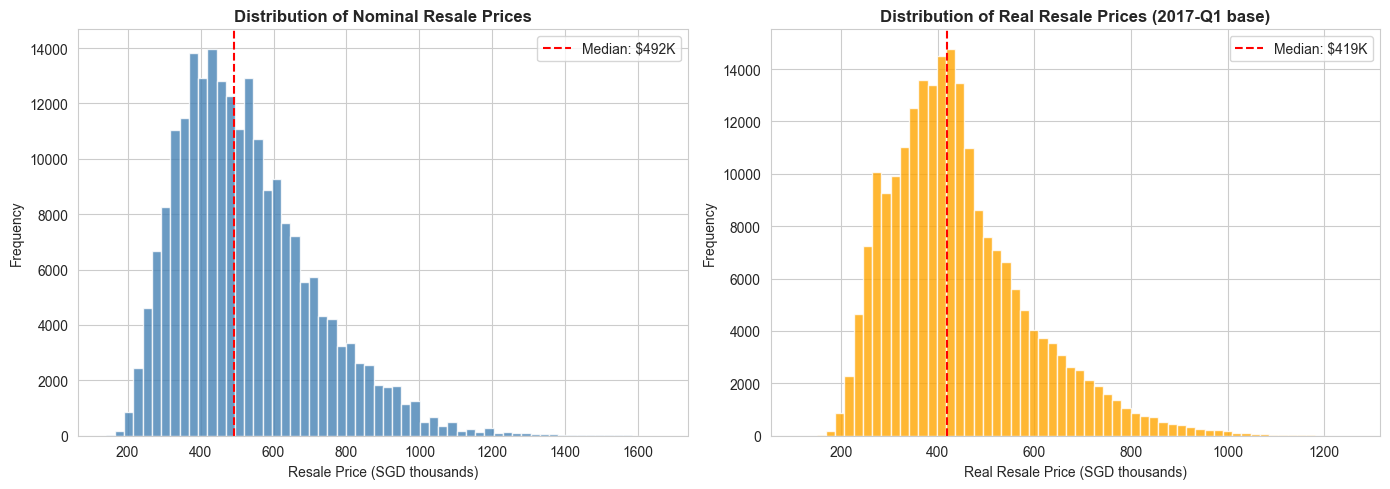

In [12]:
# Distribution of resale prices (nominal vs real)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(merged_df['resale_price'] / 1000, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Nominal Resale Prices', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Resale Price (SGD thousands)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(merged_df['resale_price'].median() / 1000, color='red', linestyle='--', label=f"Median: ${merged_df['resale_price'].median()/1000:.0f}K")
axes[0].legend()

axes[1].hist(merged_df['resale_price_real'] / 1000, bins=60, color='orange', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution of Real Resale Prices (2017-Q1 base)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Real Resale Price (SGD thousands)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(merged_df['resale_price_real'].median() / 1000, color='red', linestyle='--', label=f"Median: ${merged_df['resale_price_real'].median()/1000:.0f}K")
axes[1].legend()

plt.tight_layout()
plt.show()

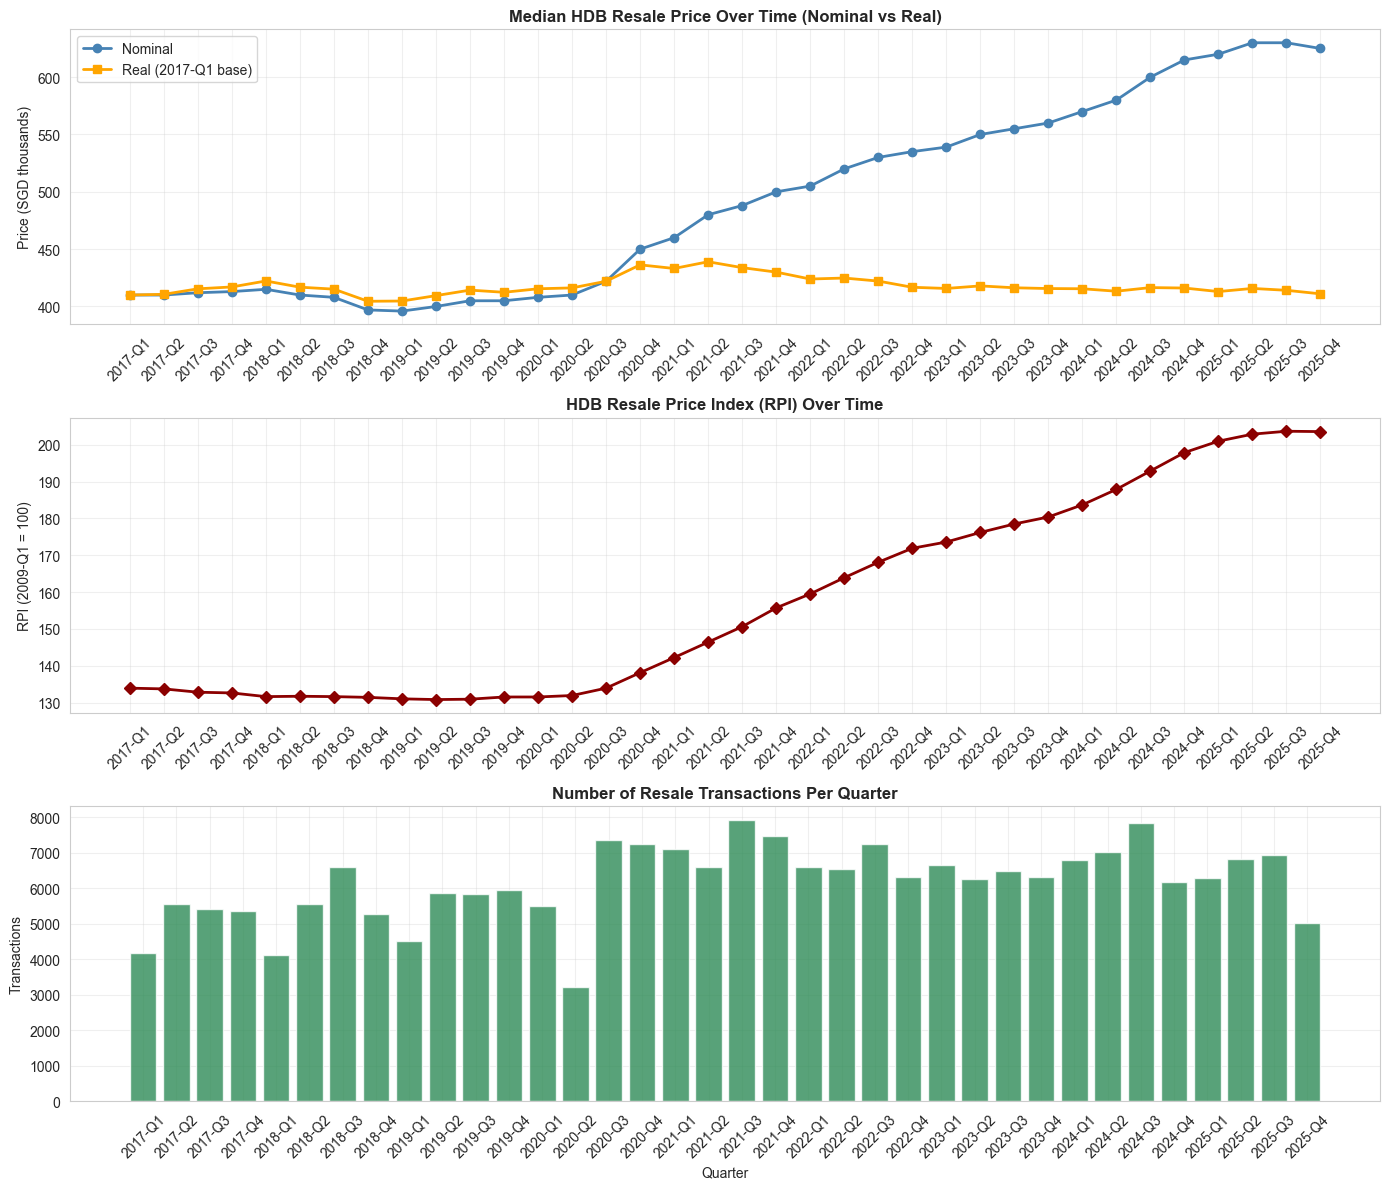

In [13]:
# Time series: Median nominal vs real resale prices and RPI
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Nominal vs Real median prices over time
axes[0].plot(quarterly_summary['quarter'], quarterly_summary['median_price'] / 1000,
             marker='o', linewidth=2, color='steelblue', label='Nominal')
axes[0].plot(quarterly_summary['quarter'], quarterly_summary['median_real_price'] / 1000,
             marker='s', linewidth=2, color='orange', label='Real (2017-Q1 base)')
axes[0].set_title('Median HDB Resale Price Over Time (Nominal vs Real)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (SGD thousands)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: RPI over time
axes[1].plot(quarterly_summary['quarter'], quarterly_summary['rpi'],
             marker='D', linewidth=2, color='darkred')
axes[1].set_title('HDB Resale Price Index (RPI) Over Time', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RPI (2009-Q1 = 100)')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: Transaction volume over time
axes[2].bar(quarterly_summary['quarter'], quarterly_summary['num_transactions'],
            color='seagreen', edgecolor='white', alpha=0.8)
axes[2].set_title('Number of Resale Transactions Per Quarter', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Transactions')
axes[2].set_xlabel('Quarter')
axes[2].grid(True, alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Users\joelc\AppData\Local\Temp\ipykernel_30212\232913428.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='flat_type', y='resale_price',


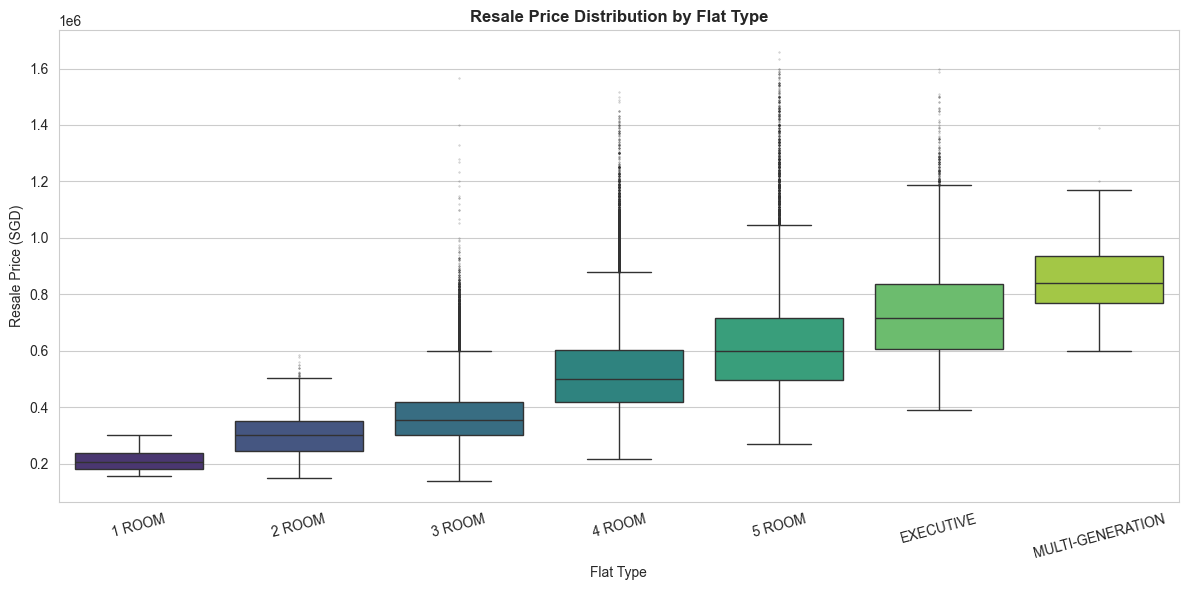

In [14]:
# Resale price distribution by flat type
fig, ax = plt.subplots(figsize=(12, 6))

flat_type_order = ['1 ROOM', '2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 'EXECUTIVE', 'MULTI-GENERATION']
plot_data = merged_df[merged_df['flat_type'].isin(flat_type_order)]

sns.boxplot(data=plot_data, x='flat_type', y='resale_price',
            order=flat_type_order, palette='viridis', ax=ax,
            flierprops=dict(marker='.', markersize=1, alpha=0.3))
ax.set_title('Resale Price Distribution by Flat Type', fontsize=12, fontweight='bold')
ax.set_xlabel('Flat Type')
ax.set_ylabel('Resale Price (SGD)')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

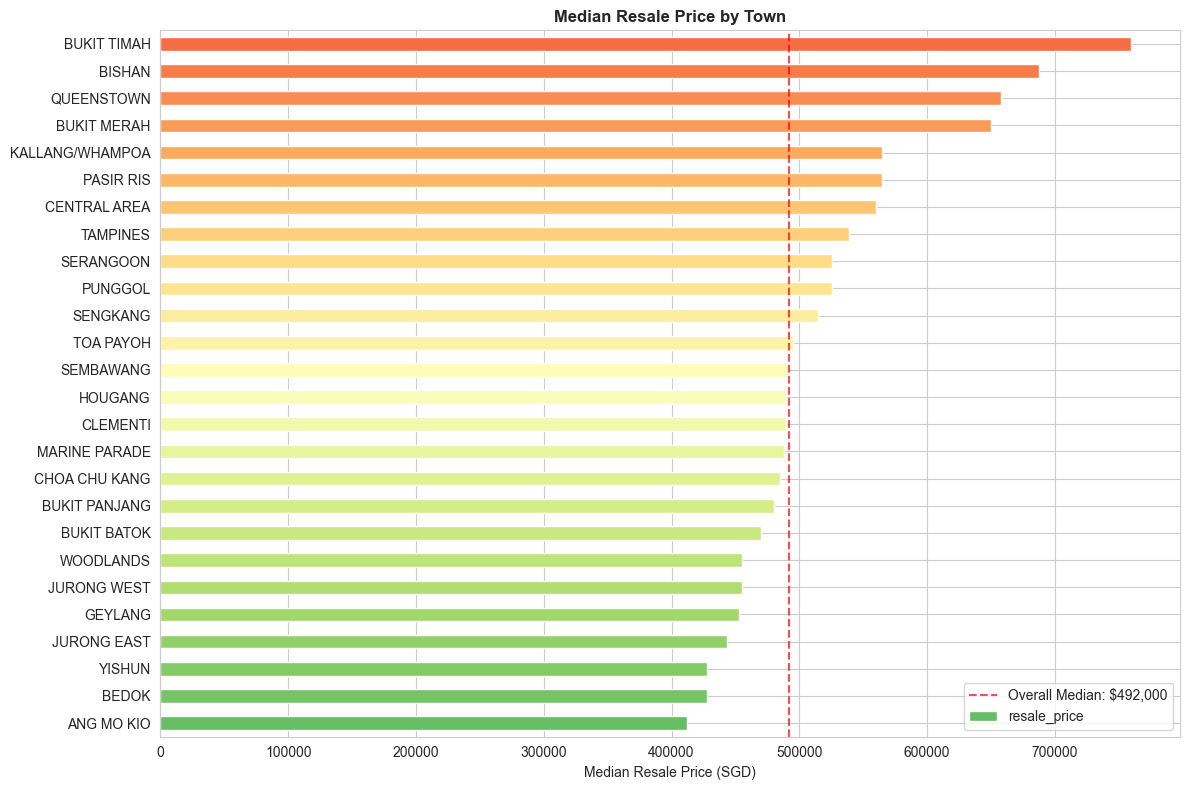

In [15]:
# Median resale price by town (horizontal bar chart)
fig, ax = plt.subplots(figsize=(12, 8))

town_median = merged_df.groupby('town')['resale_price'].median().sort_values()
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(town_median)))

town_median.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Median Resale Price by Town', fontsize=12, fontweight='bold')
ax.set_xlabel('Median Resale Price (SGD)')
ax.set_ylabel('')
ax.axvline(merged_df['resale_price'].median(), color='red', linestyle='--', alpha=0.7, label=f"Overall Median: ${merged_df['resale_price'].median():,.0f}")
ax.legend()

plt.tight_layout()
plt.show()

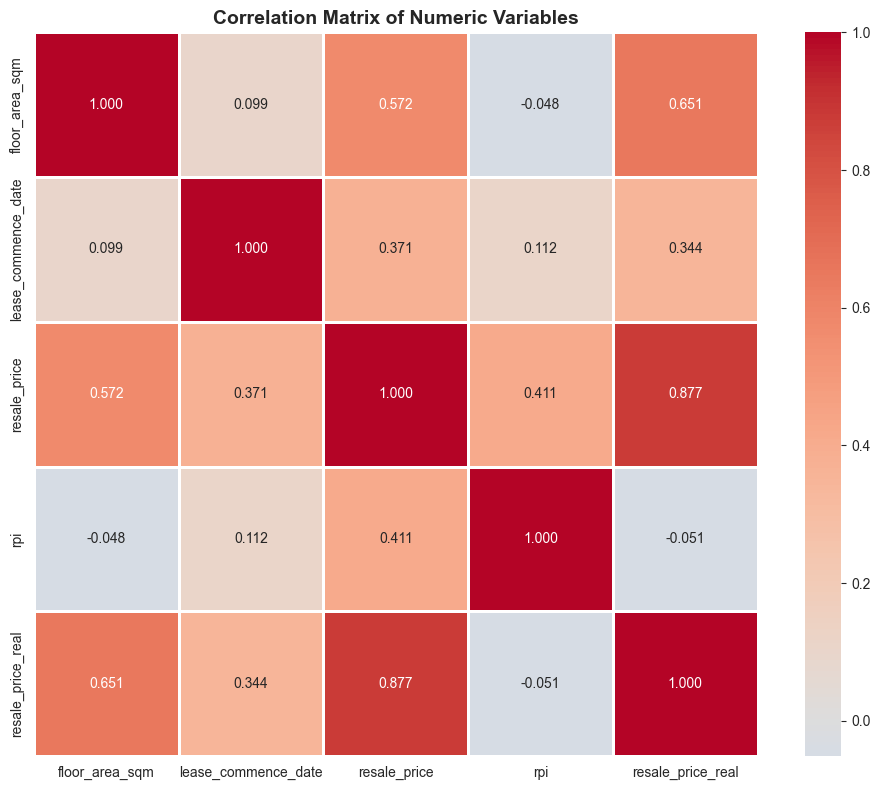


Key observations:
   - Floor area vs Resale price: 0.572
   - Lease commence date vs Resale price: 0.371
   - RPI vs Resale price: 0.411


In [16]:
# Correlation heatmap of numeric variables
fig, ax = plt.subplots(figsize=(10, 8))

numeric_cols = ['floor_area_sqm', 'lease_commence_date', 'resale_price', 'rpi', 'resale_price_real']
corr_matrix = merged_df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', square=True, linewidths=1, ax=ax)
ax.set_title('Correlation Matrix of Numeric Variables', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey observations:")
print(f"   - Floor area vs Resale price: {corr_matrix.loc['floor_area_sqm', 'resale_price']:.3f}")
print(f"   - Lease commence date vs Resale price: {corr_matrix.loc['lease_commence_date', 'resale_price']:.3f}")
print(f"   - RPI vs Resale price: {corr_matrix.loc['rpi', 'resale_price']:.3f}")

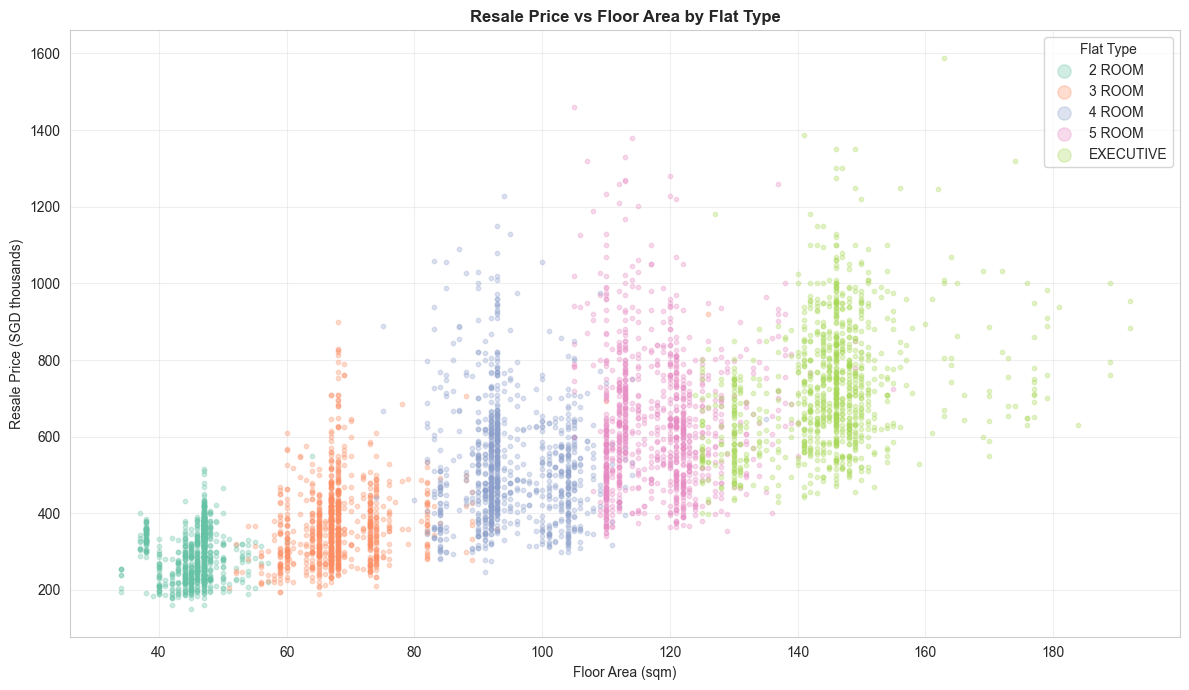

In [17]:
# Resale price vs floor area, colored by flat type
fig, ax = plt.subplots(figsize=(12, 7))

flat_types = ['2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 'EXECUTIVE']
palette = sns.color_palette('Set2', len(flat_types))

for ft, color in zip(flat_types, palette):
    subset = merged_df[merged_df['flat_type'] == ft].sample(min(1000, len(merged_df[merged_df['flat_type'] == ft])), random_state=42)
    ax.scatter(subset['floor_area_sqm'], subset['resale_price'] / 1000,
               alpha=0.3, s=10, label=ft, color=color)

ax.set_title('Resale Price vs Floor Area by Flat Type', fontsize=12, fontweight='bold')
ax.set_xlabel('Floor Area (sqm)')
ax.set_ylabel('Resale Price (SGD thousands)')
ax.legend(title='Flat Type', markerscale=3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()